In [5]:
"""Zadanie 1 – Podstawowy SELECT
Utwórz bazę danych SQLite z tabelą products zawierającą kolumny: product_id , name ,
category , price , stock . Wstaw 10 przykładowych produktów.
Wymagania:
- Napisz zapytanie SELECT wybierające wszystkie produkty
- Napisz zapytanie wybierające tylko name i price
- Wyświetl wyniki za pomocą pd.read_sql_query()
"""
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

produkty = pd.DataFrame({
    'product_id': range(1, 11),
    'name': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki', 'Kabel', 'Pendrive', 'Dysk', 'Kamera', 'Głośniki'],
    'category': ['Elektronika', 'Akcesoria', 'Akcesoria', 'Elektronika', 'Akcesoria', 'Akcesoria', 'Akcesoria', 'Elektronika', 'Elektronika', 'Elektronika'],
    'price': [3500, 50, 150, 1200, 200, 30, 40, 400, 250, 300],
    'stock': [10, 100, 50, 20, 40, 200, 150, 30, 15, 25]
})
produkty.to_sql('products', conn, index=False)

query1 = "SELECT * FROM products"
print("=== Wszystkie produkty ===")
print(pd.read_sql_query(query1, conn))

query2 = "SELECT product_id, name FROM products"
print("\n=== Tylko nazwa i cena ===")
print(pd.read_sql_query(query2, conn))

=== Wszystkie produkty ===
   product_id        name     category  price  stock
0           1      Laptop  Elektronika   3500     10
1           2        Mysz    Akcesoria     50    100
2           3  Klawiatura    Akcesoria    150     50
3           4     Monitor  Elektronika   1200     20
4           5   Słuchawki    Akcesoria    200     40
5           6       Kabel    Akcesoria     30    200
6           7    Pendrive    Akcesoria     40    150
7           8        Dysk  Elektronika    400     30
8           9      Kamera  Elektronika    250     15
9          10    Głośniki  Elektronika    300     25

=== Tylko nazwa i cena ===
   product_id        name
0           1      Laptop
1           2        Mysz
2           3  Klawiatura
3           4     Monitor
4           5   Słuchawki
5           6       Kabel
6           7    Pendrive
7           8        Dysk
8           9      Kamera
9          10    Głośniki


In [20]:
"""Zadanie 2 – WHERE z warunkami
Używając tabeli products z zadania 1:
Wymagania:
- Znajdź produkty droższe niż 100 PLN
- Znajdź produkty z kategorii "Elektronika" LUB z ceną < 50 PLN
- Znajdź produkty z zapasem (stock) między 10 a 50
"""

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

produkty = pd.DataFrame({
    'product_id': range(1, 11),
    'name': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki', 'Kabel', 'Pendrive', 'Dysk', 'Kamera', 'Głośniki'],
    'category': ['Elektronika', 'Akcesoria', 'Akcesoria', 'Elektronika', 'Akcesoria', 'Akcesoria', 'Akcesoria', 'Elektronika', 'Elektronika', 'Elektronika'],
    'price': [3500, 50, 150, 1200, 200, 30, 40, 400, 250, 300],
    'stock': [10, 100, 50, 20, 40, 200, 150, 30, 15, 25]
})
produkty.to_sql('products', conn, index=False)

query3 = """
SELECT * FROM products
WHERE price > 100
"""
print("=== Products more expensive then 100 ===")
print(pd.read_sql_query(query3, conn))

query4 = """
SELECT * FROM products
WHERE category = 'Elektronika' OR price < 50
"""
print("\n ===Products as electronics or with price smoller than 50")
print(pd.read_sql_query(query4, conn))

query5 = """
SELECT * FROM products
WHERE stock BETWEEN 10 AND 50
""" 
print("\n ===Products with stock between 10 and 50")
print(pd.read_sql_query(query5, conn))

=== Products more expensive then 100 ===
   product_id        name     category  price  stock
0           1      Laptop  Elektronika   3500     10
1           3  Klawiatura    Akcesoria    150     50
2           4     Monitor  Elektronika   1200     20
3           5   Słuchawki    Akcesoria    200     40
4           8        Dysk  Elektronika    400     30
5           9      Kamera  Elektronika    250     15
6          10    Głośniki  Elektronika    300     25

 ===Products as electronics or with price smoller than 50
   product_id      name     category  price  stock
0           1    Laptop  Elektronika   3500     10
1           4   Monitor  Elektronika   1200     20
2           6     Kabel    Akcesoria     30    200
3           7  Pendrive    Akcesoria     40    150
4           8      Dysk  Elektronika    400     30
5           9    Kamera  Elektronika    250     15
6          10  Głośniki  Elektronika    300     25

 ===Products with stock between 10 and 50
   product_id        name

In [27]:
"""Zadanie 3 – ORDER BY i LIMIT
Wymagania:
- Wyświetl 5 najdroższych produktów
- Wyświetl 5 produktów z najmniejszym zapasem
- Wyświetl produkty posortowane alfabetycznie po nazwie
"""

import sqlite3
import pandas as pd

query6 = """
SELECT * FROM products
ORDER BY price DESC
LIMIT 5
"""
print("=== 5 most expensive products ===")
print(pd.read_sql_query(query6, conn))

query7 = """
SELECT * FROM products
ORDER BY stock
LIMIT 5
"""
print("\n5 products with the smallest stock")
print(pd.read_sql_query(query7, conn))

query8 = """
SELECT * FROM products
ORDER BY name
"""
print("\n Products with names sort by alphabet")
print(pd.read_sql_query(query8, conn))

=== 5 most expensive products ===
   product_id      name     category  price  stock
0           1    Laptop  Elektronika   3500     10
1           4   Monitor  Elektronika   1200     20
2           8      Dysk  Elektronika    400     30
3          10  Głośniki  Elektronika    300     25
4           9    Kamera  Elektronika    250     15

5 products with the smallest stock
   product_id      name     category  price  stock
0           1    Laptop  Elektronika   3500     10
1           9    Kamera  Elektronika    250     15
2           4   Monitor  Elektronika   1200     20
3          10  Głośniki  Elektronika    300     25
4           8      Dysk  Elektronika    400     30

 Products with names sort by alphabet
   product_id        name     category  price  stock
0           8        Dysk  Elektronika    400     30
1          10    Głośniki  Elektronika    300     25
2           6       Kabel    Akcesoria     30    200
3           9      Kamera  Elektronika    250     15
4           3 

In [58]:
"""Zadanie 4 – Podstawowy JOIN
Utwórz dwie tabele: customers (customer_id, name, city) i orders (order_id,
customer_id, amount).
Wymagania:
- Wykonaj INNER JOIN łączący klientów z zamówieniami
- Wyświetl nazwę klienta, miasto i kwotę zamówienia
- Posortuj wyniki według kwoty malejąco
"""

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

df_customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'name': ['Marta', 'Jan Kowalski', 'Anna Wójcik', 'Piotr Zieliński', 'Katarzyna Lis'],
    'city': ['Kraków', 'Warszawa', 'Gdańsk', 'Wrocław', 'Poznań']
})
df_customers.to_sql('customers', conn, index=False)

df_orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106],
    'customer_id': [1, 2, 1, 3, 5, 2], 
    'amount': [250.00, 120.50, 450.00, 89.99, 1000.00, 50.00]
})
df_orders.to_sql('orders', conn, index=False)

query9 = """
SELECT
    c.name,
    c.city,
    o.amount
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
ORDER BY o.amount DESC
"""
print("=== INNER JOIN - name, city, amount(descending) ===")
print(pd.read_sql_query(query9, conn))

=== INNER JOIN - name, city, amount(descending) ===
            name      city   amount
0  Katarzyna Lis    Poznań  1000.00
1          Marta    Kraków   450.00
2          Marta    Kraków   250.00
3   Jan Kowalski  Warszawa   120.50
4    Anna Wójcik    Gdańsk    89.99
5   Jan Kowalski  Warszawa    50.00


In [71]:
"""Zadanie 5 – LEFT JOIN
Używając tabel z zadania 4:
Wymagania:
- Wykonaj LEFT JOIN pokazujący WSZYSTKICH klientów (nawet bez zamówień)
- Użyj COALESCE aby zamienić NULL na 0 w kwocie zamówienia
- Znajdź klientów którzy NIE złożyli zamówienia (WHERE order_id IS NULL)
"""

query10 = """
SELECT
    c.customer_id,
    c.name,
    c.city,
    COUNT(o.order_id) AS number_of_orders,
    COALESCE(SUM(o.amount), 0) AS total_spent
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name, c.city
ORDER BY total_spent
"""

print("=== All customers ===")
print(pd.read_sql_query(query10, conn))

query11 = """
SELECT
    c.customer_id,
    c.name,
    c.city
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
WHERE order_id IS NULL
"""

print("\n=== Customers without order ===")
print(pd.read_sql_query(query11, conn))

=== All customers ===
   customer_id             name      city  number_of_orders  total_spent
0            4  Piotr Zieliński   Wrocław                 0         0.00
1            3      Anna Wójcik    Gdańsk                 1        89.99
2            2     Jan Kowalski  Warszawa                 2       170.50
3            1            Marta    Kraków                 2       700.00
4            5    Katarzyna Lis    Poznań                 1      1000.00

=== Customers without order ===
   customer_id             name     city
0            4  Piotr Zieliński  Wrocław


In [88]:
"""Zadanie 6 – Podstawowy GROUP BY
Używając tabeli orders :
Wymagania:
- Policz liczbę zamówień dla każdego klienta
- Oblicz łączną kwotę zamówień dla każdego klienta
- Oblicz średnią wartość zamówienia dla każdego klienta
"""

import pandas as pd
import sqlite3

conn = sqlite3.connect(':memory:')

df_customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'name': ['Marta', 'Jan Kowalski', 'Anna Wójcik', 'Piotr Zieliński', 'Katarzyna Lis'],
    'city': ['Kraków', 'Warszawa', 'Gdańsk', 'Wrocław', 'Poznań']
})
df_customers.to_sql('customers', conn, index=False)

df_orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106],
    'customer_id': [1, 2, 1, 3, 5, 2], 
    'amount': [250.00, 120.50, 450.00, 89.99, 1000.00, 50.00]
})
df_orders.to_sql('orders', conn, index=False)

query12 = """
SELECT
    c.customer_id,
    c.name,
    COUNT(o.order_id) AS number_of_orders,
    COALESCE(SUM(o.amount), 0) AS total_spent,
    COALESCE(AVG(o.amount), 0) AS average_order_value
FROM customers c
LEFT JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name
ORDER BY c.customer_id
"""

print("=== Number of orders for each customer ===")
print(pd.read_sql_query(query12, conn))

print("=== ")




=== Number of orders for each customer ===
   customer_id             name  number_of_orders  total_spent  \
0            1            Marta                 2       700.00   
1            2     Jan Kowalski                 2       170.50   
2            3      Anna Wójcik                 1        89.99   
3            4  Piotr Zieliński                 0         0.00   
4            5    Katarzyna Lis                 1      1000.00   

   average_order_value  
0               350.00  
1                85.25  
2                89.99  
3                 0.00  
4              1000.00  
=== 


In [109]:
"""Zadanie 7 – COUNT i SUM
Wymagania:
- Policz łączną liczbę produktów w tabeli products
- Oblicz łączną wartość zapasów (stock * price) dla wszystkich produktów
- Oblicz średnią cenę produktów w każdej kategorii
"""
import pandas as pd
import sqlite3

conn = sqlite3.connect(':memory:')

produkty = pd.DataFrame({
    'product_id': range(1, 11),
    'name': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki', 'Kabel', 'Pendrive', 'Dysk', 'Kamera', 'Głośniki'],
    'category': ['Elektronika', 'Akcesoria', 'Akcesoria', 'Elektronika', 'Akcesoria', 'Akcesoria', 'Akcesoria', 'Elektronika', 'Elektronika', 'Elektronika'],
    'price': [3500, 50, 150, 1200, 200, 30, 40, 400, 250, 300],
    'stock': [10, 100, 50, 20, 40, 200, 150, 30, 15, 25]
})
produkty.to_sql('products', conn, index=False)

query13 = """
SELECT
    COUNT(product_id) AS number_of_product,
    COALESCE(SUM(stock * price), 0) AS inventory_value
FROM products
"""
print("=== Number of product and inventory value===")
print(pd.read_sql_query(query13, conn))

query14 = """
SELECT
    category,
    AVG(price) AS avr_price
FROM products
GROUP BY category
"""
print("\n === Average price in every category ===")
print(pd.read_sql_query(query14, conn))

=== Number of product and inventory value===
   number_of_product  inventory_value
0                 10           114750

 === Average price in every category ===
      category  avr_price
0    Akcesoria       94.0
1  Elektronika     1130.0


In [132]:
"""Zadanie 8 – Tworzenie indeksu
Wymagania:
- Utwórz tabelę z 10 000 rekordami (użyj pętli lub NumPy)
- Zmierz czas zapytania SELECT z filtrem WHERE BEZ indeksu
- Utwórz indeks na kolumnie filtrowanej
- Zmierz czas zapytania Z indeksem
- Porównaj wyniki
"""
import sqlite3
import pandas as pd
import numpy as np
import time

conn = sqlite3.connect(':memory:')
np.random.seed(42)

df_large = pd.DataFrame({
    'user_id' : range(1, 10001),
    'name' : [f'User_{i}' for i in range(1, 10001)],
    'city' : np.random.choice(['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Poznań'], 10000),
    'age': np.random.randint(18, 80, 10000)
})
df_large.to_sql('users', conn, index=False)

print("Large table loaded. Testing speed...\n")

# 1
query_search = """
SELECT
    name
FROM users
WHERE city = 'Kraków'
"""
start_time = time.time()
pd.read_sql_query(query_search, conn)
time_no_index = time.time() - start_time
print(f"Time without indekx: {time_no_index:.5f} s.")

# 2
query_create_index = """
CREATE INDEX idx_city ON users (city)
"""
conn.execute(query_create_index)
print("Indeks created!")

# 3
start_time = time.time()
pd.read_sql_query(query_search, conn)
time_with_index =time.time() - start_time

print(f"Time with indekx: {time_with_index:.5f}s.")
print(f"Acceleration: {time_no_index / time_with_index:.1f}x.")


Large table loaded. Testing speed...

Time without indekx: 0.00168 s.
Indeks created!
Time with indekx: 0.00087s.
Acceleration: 1.9x.


In [154]:
"""Zadanie 9 – JOIN 3 tabel
Utwórz bazę sklepu: customers , orders , order_items (zawiera szczegóły produktów w
zamówieniu).
Wymagania:
- Połącz 3 tabele w jednym zapytaniu
- Wyświetl nazwę klienta, datę zamówienia, nazwę produktu i cenę
- Oblicz łączną wartość każdego zamówienia
- Znajdź 10 największych zamówień
"""

import sqlite3
import pandas as pd
import random

conn = sqlite3.connect(':memory:')

df_customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'name': ['Marta', 'Jan Kowalski', 'Anna Wójcik', 'Piotr Zieliński', 'Katarzyna Lis'],
    'city': ['Kraków', 'Warszawa', 'Gdańsk', 'Wrocław', 'Poznań']  
})
df_customers.to_sql('customers', conn, index=False)

df_orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112],
    'customer_id': [1, 2, 1, 3, 5, 2, 3, 4, 1, 5, 2, 4],
    'order_date': ['2024-03-01', '2024-03-02', '2024-03-03', '2024-03-04', '2024-03-05', 
                    '2024-03-06', '2024-03-07', '2024-03-08', '2024-03-09', '2024-03-10',
                    '2024-03-11', '2024-03-12']    
})
df_orders.to_sql('orders', conn, index=False)

items_data = [
    (1, 101, 'Laptop', 3500.00, 1), (2, 101, 'Mysz', 50.00, 1),
    (3, 102, 'Słuchawki', 200.00, 1), (4, 103, 'Monitor', 1200.00, 2),
    (5, 104, 'Kabel', 30.00, 5), (6, 105, 'Smartfon', 2500.00, 1),
    (7, 105, 'Etui', 80.00, 1), (8, 106, 'Klawiatura', 150.00, 1),
    (9, 107, 'Dysk SSD', 400.00, 1), (10, 108, 'Kamera', 250.00, 1),
    (11, 109, 'Głośniki', 300.00, 2), (12, 110, 'Tablet', 1500.00, 1),
    (13, 111, 'Pendrive', 40.00, 10), (14, 112, 'Zasilacz', 120.00, 1),
    (15, 101, 'Torba', 100.00, 1), (16, 105, 'Szkło', 50.00, 1)
]
df_items = pd.DataFrame(items_data, columns=['item_id', 'order_id', 'product_name', 'price', 'quantity'])
df_items.to_sql('order_items', conn, index=False)

query15 = """
SELECT
    c.name AS customer_name,
    o.order_date,
    i.product_name,
    i.price
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
INNER JOIN order_items i ON o.order_id = i.order_id
ORDER BY c.name, o.order_id, i.product_name
"""
print("=== Customer name, order date, product name and price\n ===")
print(pd.read_sql_query(query15, conn))

query16 = """
SELECT
    c.name AS customer_name,
    o.order_date,
    SUM(i.price * i.quantity) AS total_order_value
FROM customers c
INNER JOIN orders o ON c.customer_id = o.customer_id
INNER JOIN order_items i ON o.order_id = i.order_id
GROUP BY o.order_id, c.name, o.order_date
ORDER BY total_order_value
LIMIT 10
"""
print("\n=== Top 10 orders===")
print(pd.read_sql_query(query16, conn))

=== Customer name, order date, product name and price
 ===
      customer_name  order_date product_name   price
0       Anna Wójcik  2024-03-04        Kabel    30.0
1       Anna Wójcik  2024-03-07     Dysk SSD   400.0
2      Jan Kowalski  2024-03-02    Słuchawki   200.0
3      Jan Kowalski  2024-03-06   Klawiatura   150.0
4      Jan Kowalski  2024-03-11     Pendrive    40.0
5     Katarzyna Lis  2024-03-05         Etui    80.0
6     Katarzyna Lis  2024-03-05     Smartfon  2500.0
7     Katarzyna Lis  2024-03-05        Szkło    50.0
8     Katarzyna Lis  2024-03-10       Tablet  1500.0
9             Marta  2024-03-01       Laptop  3500.0
10            Marta  2024-03-01         Mysz    50.0
11            Marta  2024-03-01        Torba   100.0
12            Marta  2024-03-03      Monitor  1200.0
13            Marta  2024-03-09     Głośniki   300.0
14  Piotr Zieliński  2024-03-08       Kamera   250.0
15  Piotr Zieliński  2024-03-12     Zasilacz   120.0

=== Top 10 orders===
     customer_name

In [155]:
"""Zadanie 10 – HAVING i grupowanie
Wymagania:
- Używając danych sprzedażowych, pogrupuj według kategorii
- Użyj HAVING aby znaleźć tylko kategorie z przychodem > 1000 PLN
- Oblicz liczbę transakcji, łączny przychód i średnią dla każdej kategorii
- Posortuj według łącznego przychodu
"""

import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')

sales_df = pd.DataFrame({
    'sale_id': range(1, 21),
    'product': ['Laptop', 'Mysz', 'Klawiatura', 'Monitor', 'Słuchawki'] * 4,
    'category': (['Elektronika'] * 2 + ['Akcesoria'] * 3) * 4,
    'revenue': [3500, 50, 200, 1200, 150, 3600, 45, 210, 1250, 140, 
                3400, 55, 190, 1180, 160, 3550, 48, 205, 1220, 155]
})
sales_df.to_sql('sales', conn, index=False)

query17 = """
SELECT
    category,
    COUNT(sale_id) AS number_of_transactions,
    SUM(revenue) AS total_revenue,
    AVG(revenue) AS average_revenue
FROM sales
GROUP BY category
HAVING SUM(revenue) > 1000
ORDER BY total_revenue DESC
"""

print("=== Sales report by category (Revenue > PLN 1,000) ===")
print(pd.read_sql_query(query17, conn))

=== Sales report by category (Revenue > PLN 1,000) ===
      category  number_of_transactions  total_revenue  average_revenue
0  Elektronika                       8          14248      1781.000000
1    Akcesoria                      12           6260       521.666667


=== 1st class passengers: women who survived ===
                                                 Name
0   Cumings, Mrs. John Bradley (Florence Briggs Th...
1        Futrelle, Mrs. Jacques Heath (Lily May Peel)
2                            Bonnell, Miss. Elizabeth
3      Spencer, Mrs. William Augustus (Marie Eugenie)
4            Harper, Mrs. Henry Sleeper (Myna Haxtun)
..                                                ...
86         Wick, Mrs. George Dennick (Mary Hitchcock)
87  Swift, Mrs. Frederick Joel (Margaret Welles Ba...
88   Beckwith, Mrs. Richard Leonard (Sallie Monypeny)
89      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)
90                       Graham, Miss. Margaret Edith

[91 rows x 1 columns]


=== Comparison Table: Female Survivors (1st Class) vs Male Victims (3rd Class) ===
      Sex  Pclass  Survived    avg_age  avg_ticket_price
0  female       1         1  34.939024        105.978159
1    male       3         0  27.255814         12.204469


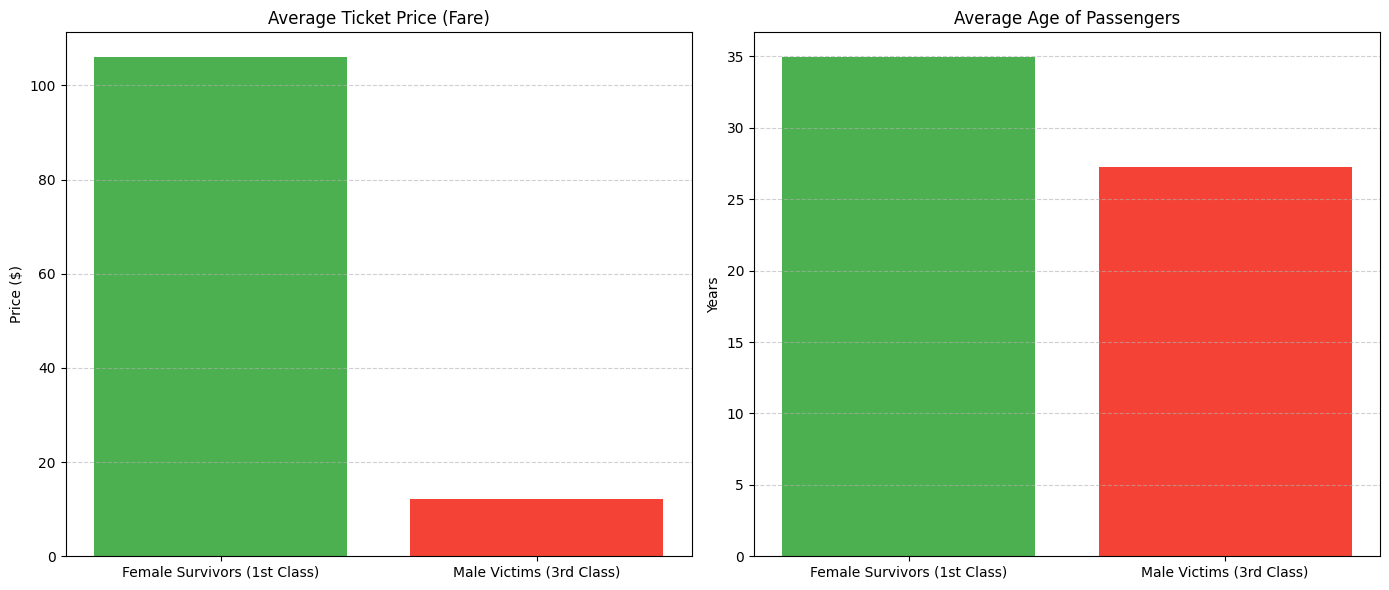

In [ ]:
"""Zadanie 11 – Złożone filtrowanie
Dataset: Titanic
Wymagania:
- Znajdź pasażerów 1 klasy, kobiety, które przeżyły
- Oblicz średni wiek i średnią cenę biletu dla tej grupy
- Porównaj z mężczyznami z 3 klasy którzy nie przeżyli
- Stwórz wykres porównawczy (barplot)
"""

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

conn = sqlite3.connect('titanic.db')
titanic.to_sql('passengers', conn, if_exists='replace', index=False)

# --- REQUIREMENT 1: List of specific passengers ---
query18 = """
SELECT
    Name
FROM passengers
WHERE sex = 'female' AND Survived = 1 AND Pclass = 1
"""
print("=== 1st class passengers: women who survived ===")
print(pd.read_sql_query(query18, conn))
print("\n")

# --- REQUIREMENTS 2 & 3: Statistics and Comparison ---
query_comparison = """
SELECT
    Sex,
    Pclass,
    Survived,
    AVG(Age) AS avg_age,
    AVG(Fare) AS avg_ticket_price
FROM passengers
WHERE (Sex = 'female' AND Pclass = 1 AND Survived = 1)
   OR (Sex = 'male' AND Pclass = 3 AND Survived = 0)
GROUP BY Sex, Pclass, Survived
"""
print("=== Comparison Table: Female Survivors (1st Class) vs Male Victims (3rd Class) ===")
df_comp = pd.read_sql_query(query_comparison, conn)
print(df_comp)

# --- REQUIREMENT 4: Comparative Visualization (Bar Plots) ---
# Extracting values from df_comp for the charts
row_women = df_comp[df_comp['Sex'] == 'female']
row_men = df_comp[df_comp['Sex'] == 'male']

# Data for plotting
labels = ['Female Survivors (1st Class)', 'Male Victims (3rd Class)']
fare_values = [row_women['avg_ticket_price'].values[0], row_men['avg_ticket_price'].values[0]]
age_values = [row_women['avg_age'].values[0], row_men['avg_age'].values[0]]

# Creating two subplots: one for Ticket Price (Fare) and one for Age
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#4CAF50', '#F44336'] # Green for survivors, Red for victims

# Plot 1: Average Ticket Price
ax1.bar(labels, fare_values, color=colors)
ax1.set_title('Average Ticket Price (Fare)')
ax1.set_ylabel('Price ($)')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Plot 2: Average Age
ax2.bar(labels, age_values, color=colors)
ax2.set_title('Average Age of Passengers')
ax2.set_ylabel('Years')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Final layout adjustments
plt.tight_layout()
plt.show()

# Close the database connection
conn.close()